<h1 style="text-align: center;">
    <b>UTS Machine Learning</b>
</h1>

<h2 style="text-align: center;">
    Wine Quality Classification
</h2>

<br>

**Nama**  : Ridho Sulistiono  
**NIM**   : 2304010035  
**Prodi** : D3 Statistika Terapan dan Komputasi  

---

Dataset yang digunakan dalam analisis ini terdiri dari 857 baris data dengan 13 variabel, yang merepresentasikan berbagai karakteristik kimiawi dari sampel anggur. Variabel yang menjadi fokus utama adalah quality, yang menunjukkan tingkat kualitas anggur dan akan digunakan sebagai target dalam proses pemodelan.

Tujuan: Melakukan Klasifikasi untuk memprediksi nilai kualitas anggur (quality: skala 0–10) berdasarkan fitur-fitur kimiawi yang tersedia, menggunakan algoritma machine learning yang sesuai.


# 1. Import Library

In [40]:
import math
import time
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler,
    RobustScaler
)

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold
)

from imblearn.over_sampling import SMOTE


from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    HistGradientBoostingClassifier,
    VotingClassifier
)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from sklearn.model_selection import (
    GridSearchCV,
    cross_val_score,
    cross_validate
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from skopt import BayesSearchCV
from skopt.space import (
    Real,
    Integer,
    Categorical
)

from imblearn.pipeline import Pipeline
from IPython.display import display, Markdown
from collections import Counter

print("Berhasil import semua library")

Berhasil import semua library


# 2. Memuat Data

Terdapat dua dataset yang digunakan:
- `data_training.csv` → dataset yang digunakan untuk melatih model (memiliki label)
- `data_testing.csv` → dataset yang digunakan untuk melakukan prediksi *quality* tanpa label

In [3]:
# load dataset
df_train_raw = pd.read_csv("data_training.csv")
df_testing_raw = pd.read_csv("data_testing.csv")

In [4]:
display(Markdown("### Preview Dataset Data Training"))
df_train_raw.head()

### Preview Dataset Data Training

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.3,0.740,0.08,1.7,0.094,10.0,45.0,0.99576,3.24,0.50,9.8,5,1366
1,8.1,0.575,0.22,2.1,0.077,12.0,65.0,0.99670,3.29,0.51,9.2,5,103
2,10.1,0.430,0.40,2.6,0.092,13.0,52.0,0.99834,3.22,0.64,10.0,7,942
3,12.9,0.500,0.55,2.8,0.072,7.0,24.0,1.00012,3.09,0.68,10.9,6,811
4,8.4,0.360,0.32,2.2,0.081,32.0,79.0,0.99640,3.30,0.72,11.0,6,918


In [5]:
display(Markdown("### Preview Dataset Data Testing"))
df_testing_raw.head()

### Preview Dataset Data Testing

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,Id
0,6.8,0.61,0.04,1.5,0.057,5.0,10.0,0.99525,3.42,0.60,9.500000,222
1,6.9,0.84,0.21,4.1,0.074,16.0,65.0,0.99842,3.53,0.72,9.233333,1514
2,7.0,0.58,0.12,1.9,0.091,34.0,124.0,0.99560,3.44,0.48,10.500000,417
3,7.8,0.48,0.68,1.7,0.415,14.0,32.0,0.99656,3.09,1.06,9.100000,754
4,12.5,0.60,0.49,4.3,0.100,5.0,14.0,1.00100,3.25,0.74,11.900000,516


# 3. Exploratory Data Analysis (EDA)

EDA (Exploratory Data Analysis) dilakukan untuk memahami karakteristik data sebelum proses pemodelan machine learning dilakukan. Tahapan analisis meliputi:

- Identifikasi `tipe data` setiap fitur untuk memastikan kesesuaian format data
- Analisis `statistik deskriptif` untuk memahami distribusi dan sebaran data
- Pemeriksaan *`missing values`* untuk mendeteksi data yang tidak lengkap
- Pemeriksaan `duplikasi data` untuk menghindari redundansi observasi
- Analisis `distribusi variabel target` *quality* untuk mengetahui keseimbangan kelas
- Analisis `distribusi setiap fitur` untuk memahami pola dan karakteristik data
- Analisis `korelasi fitur terhadap target` untuk mengidentifikasi fitur yang berpengaruh
- Analisis `korelasi antar fitur` untuk mendeteksi potensi multikolinearitas
- Deteksi *`outlier`* menggunakan metode Interquartile Range (IQR) dan voxplot

## 3.1 Tipe Data

In [6]:
# informasi dataset
display(Markdown("### Informasi Dataset Data Training"))
df_train_raw.info()

display(Markdown("### Informasi Dataset Data Testing"))
df_testing_raw.info()

### Informasi Dataset Data Training

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 857 entries, 0 to 856
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         857 non-null    float64
 1   volatile acidity      857 non-null    float64
 2   citric acid           857 non-null    float64
 3   residual sugar        857 non-null    float64
 4   chlorides             857 non-null    float64
 5   free sulfur dioxide   857 non-null    float64
 6   total sulfur dioxide  857 non-null    float64
 7   density               857 non-null    float64
 8   pH                    857 non-null    float64
 9   sulphates             857 non-null    float64
 10  alcohol               857 non-null    float64
 11  quality               857 non-null    int64  
 12  Id                    857 non-null    int64  
dtypes: float64(11), int64(2)
memory usage: 87.2 KB


### Informasi Dataset Data Testing

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 286 entries, 0 to 285
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         286 non-null    float64
 1   volatile acidity      286 non-null    float64
 2   citric acid           286 non-null    float64
 3   residual sugar        286 non-null    float64
 4   chlorides             286 non-null    float64
 5   free sulfur dioxide   286 non-null    float64
 6   total sulfur dioxide  286 non-null    float64
 7   density               286 non-null    float64
 8   pH                    286 non-null    float64
 9   sulphates             286 non-null    float64
 10  alcohol               286 non-null    float64
 11  Id                    286 non-null    int64  
dtypes: float64(11), int64(1)
memory usage: 26.9 KB


Berdasarkan informasi dataset, data training memiliki 857 baris dan 13 kolom, sedangkan data testing memiliki 286 baris dan 12 kolom. Seluruh fitur numerik bertipe `float64`, sementara variabel `quality` dan `Id` bertipe `int64`.

Dataset training memiliki kolom `quality` sebagai variabel target yang digunakan dalam proses pelatihan model klasifikasi. Sementara itu, dataset testing tidak memiliki kolom `quality` karena digunakan untuk proses prediksi menggunakan model yang telah dilatih

## 3.2 Deskripsi Data

In [7]:
display(Markdown("### Deskripsi Dataset Data Training"))
df_train_raw.describe().T


### Deskripsi Dataset Data Training

,count,mean,std,min,25%,50%,75%,max
fixed acidity,857.0,8.261960,1.701992,4.60000,7.10000,7.90000,9.1000,15.6000
volatile acidity,857.0,0.529393,0.179162,0.12000,0.39500,0.52000,0.6400,1.5800
citric acid,857.0,0.267351,0.195144,0.00000,0.09000,0.25000,0.4200,1.0000
residual sugar,857.0,2.506184,1.293512,0.90000,1.90000,2.20000,2.6000,15.5000
chlorides,857.0,0.086830,0.048721,0.01200,0.07000,0.07900,0.0900,0.6110
free sulfur dioxide,857.0,15.782964,10.300402,1.00000,7.00000,14.00000,21.0000,68.0000
total sulfur dioxide,857.0,45.978413,31.692113,6.00000,21.00000,38.00000,63.0000,278.0000
density,857.0,0.996692,0.001901,0.99007,0.99552,0.99668,0.9978,1.0032
pH,857.0,3.313092,0.152079,2.74000,3.21000,3.31000,3.4000,4.0100
sulphates,857.0,0.656709,0.167364,0.39000,0.55000,0.62000,0.7300,2.0000


Berdasarkan statistik deskriptif, seluruh fitur pada dataset memiliki tipe numerik dengan rentang nilai yang berbeda-beda. Variabel target `quality` memiliki nilai minimum 3 dan maksimum 8 dengan rata-rata sebesar 5.65, yang menunjukkan bahwa sebagian besar kualitas wine berada pada kategori menengah.

Beberapa fitur seperti `residual sugar`, `chlorides`, dan `total sulfur dioxide` memiliki nilai maksimum yang cukup jauh dari kuartil atas (Q3), sehingga mengindikasikan adanya potensi *outlier*. Selain itu, perbedaan skala antar fitur terlihat cukup signifikan, misalnya pada fitur `density` yang memiliki rentang sangat kecil dibandingkan `total sulfur dioxide`. Kondisi ini menunjukkan bahwa proses normalisasi atau scaling berpotensi diperlukan pada tahap preprocessing, terutama untuk model yang sensitif terhadap skala data.

## 3.3 Missing Values

In [8]:
# cek missing values data training
missing_train = df_train_raw.isnull().sum()

tabel_missing_train = pd.DataFrame({
    'Jumlah Missing': missing_train,
    'Persentase (%)': (missing_train / len(df_train_raw) * 100).round(2)
}).sort_values('Persentase (%)', ascending=False)

display(Markdown("### Missing Values Data Training"))
tabel_missing_train

### Missing Values Data Training

,Jumlah Missing,Persentase (%)
fixed acidity,0,0.0
volatile acidity,0,0.0
citric acid,0,0.0
residual sugar,0,0.0
chlorides,0,0.0
free sulfur dioxide,0,0.0
total sulfur dioxide,0,0.0
density,0,0.0
pH,0,0.0
sulphates,0,0.0


In [9]:
# cek missing values data testing
missing_testing = df_testing_raw.isnull().sum()

tabel_missing_testing = pd.DataFrame({
    'Jumlah Missing': missing_testing,
    'Persentase (%)': (missing_testing / len(df_testing_raw) * 100).round(2)
}).sort_values('Persentase (%)', ascending=False)

display(Markdown("### Missing Values Data Testing"))
tabel_missing_testing

### Missing Values Data Testing

,Jumlah Missing,Persentase (%)
fixed acidity,0,0.0
volatile acidity,0,0.0
citric acid,0,0.0
residual sugar,0,0.0
chlorides,0,0.0
free sulfur dioxide,0,0.0
total sulfur dioxide,0,0.0
density,0,0.0
pH,0,0.0
sulphates,0,0.0


Tidak ditemukan *missing values* pada data training dan data testing. Dengan demikian, tidak diperlukan proses penanganan *missing values* pada tahap preprocessing.

## 3.4 Duplikasi Data

In [10]:
# cek duplikasi
print(f'Jumlah baris duplikat pada Data Training : {df_train_raw.duplicated().sum()}')
print(f'Jumlah baris duplikat pada Data Testing  : {df_testing_raw.duplicated().sum()}')

Jumlah baris duplikat pada Data Training : 0
Jumlah baris duplikat pada Data Testing  : 0


Tidak ditemukan data duplikat pada dataset, sehingga tidak diperlukan proses penghapusan duplikasi.

## 3.5 Distribusi Target

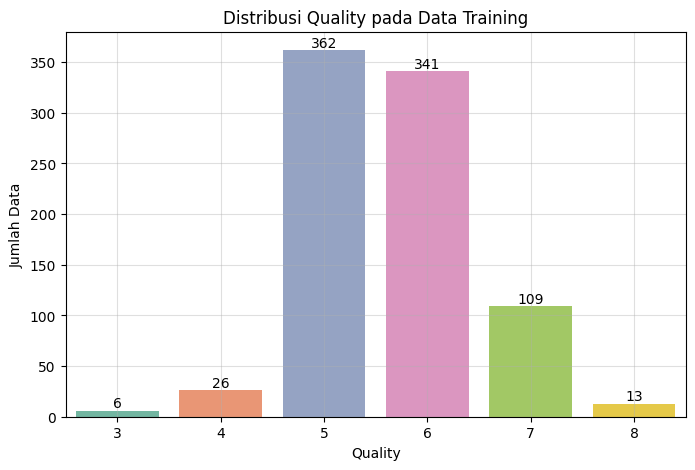

In [11]:
plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=df_train_raw,
    x='quality',
    hue='quality',
    palette='Set2',
    legend=False
)

for p in ax.patches:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.title('Distribusi Quality pada Data Training')
plt.xlabel('Quality')
plt.ylabel('Jumlah Data')

plt.grid(
    alpha=0.4,
    linestyle='-'
)

plt.show()

Berdasarkan distribusi variabel target `quality`, terlihat bahwa dataset memiliki kondisi *class imbalance* yang cukup signifikan. Kelas kualitas 5 dan 6 mendominasi jumlah data dengan masing-masing sebanyak 362 dan 341 observasi. Sementara itu, kelas 3, 4, dan 8 memiliki jumlah data yang sangat sedikit, yaitu hanya 6, 26, dan 13 observasi. Kondisi ini menunjukkan adanya *extreme imbalance* pada beberapa kelas minoritas. Jika tidak ditangani, model cenderung lebih fokus mempelajari kelas mayoritas sehingga performa prediksi pada kelas minoritas dapat menurun.

Untuk mengatasi permasalahan tersebut, pada tahap preprocessing akan diterapkan teknik *oversampling* menggunakan SMOTE (*Synthetic Minority Over-sampling Technique*) agar distribusi kelas menjadi lebih seimbang.

## 3.6 Distribusi Fitur

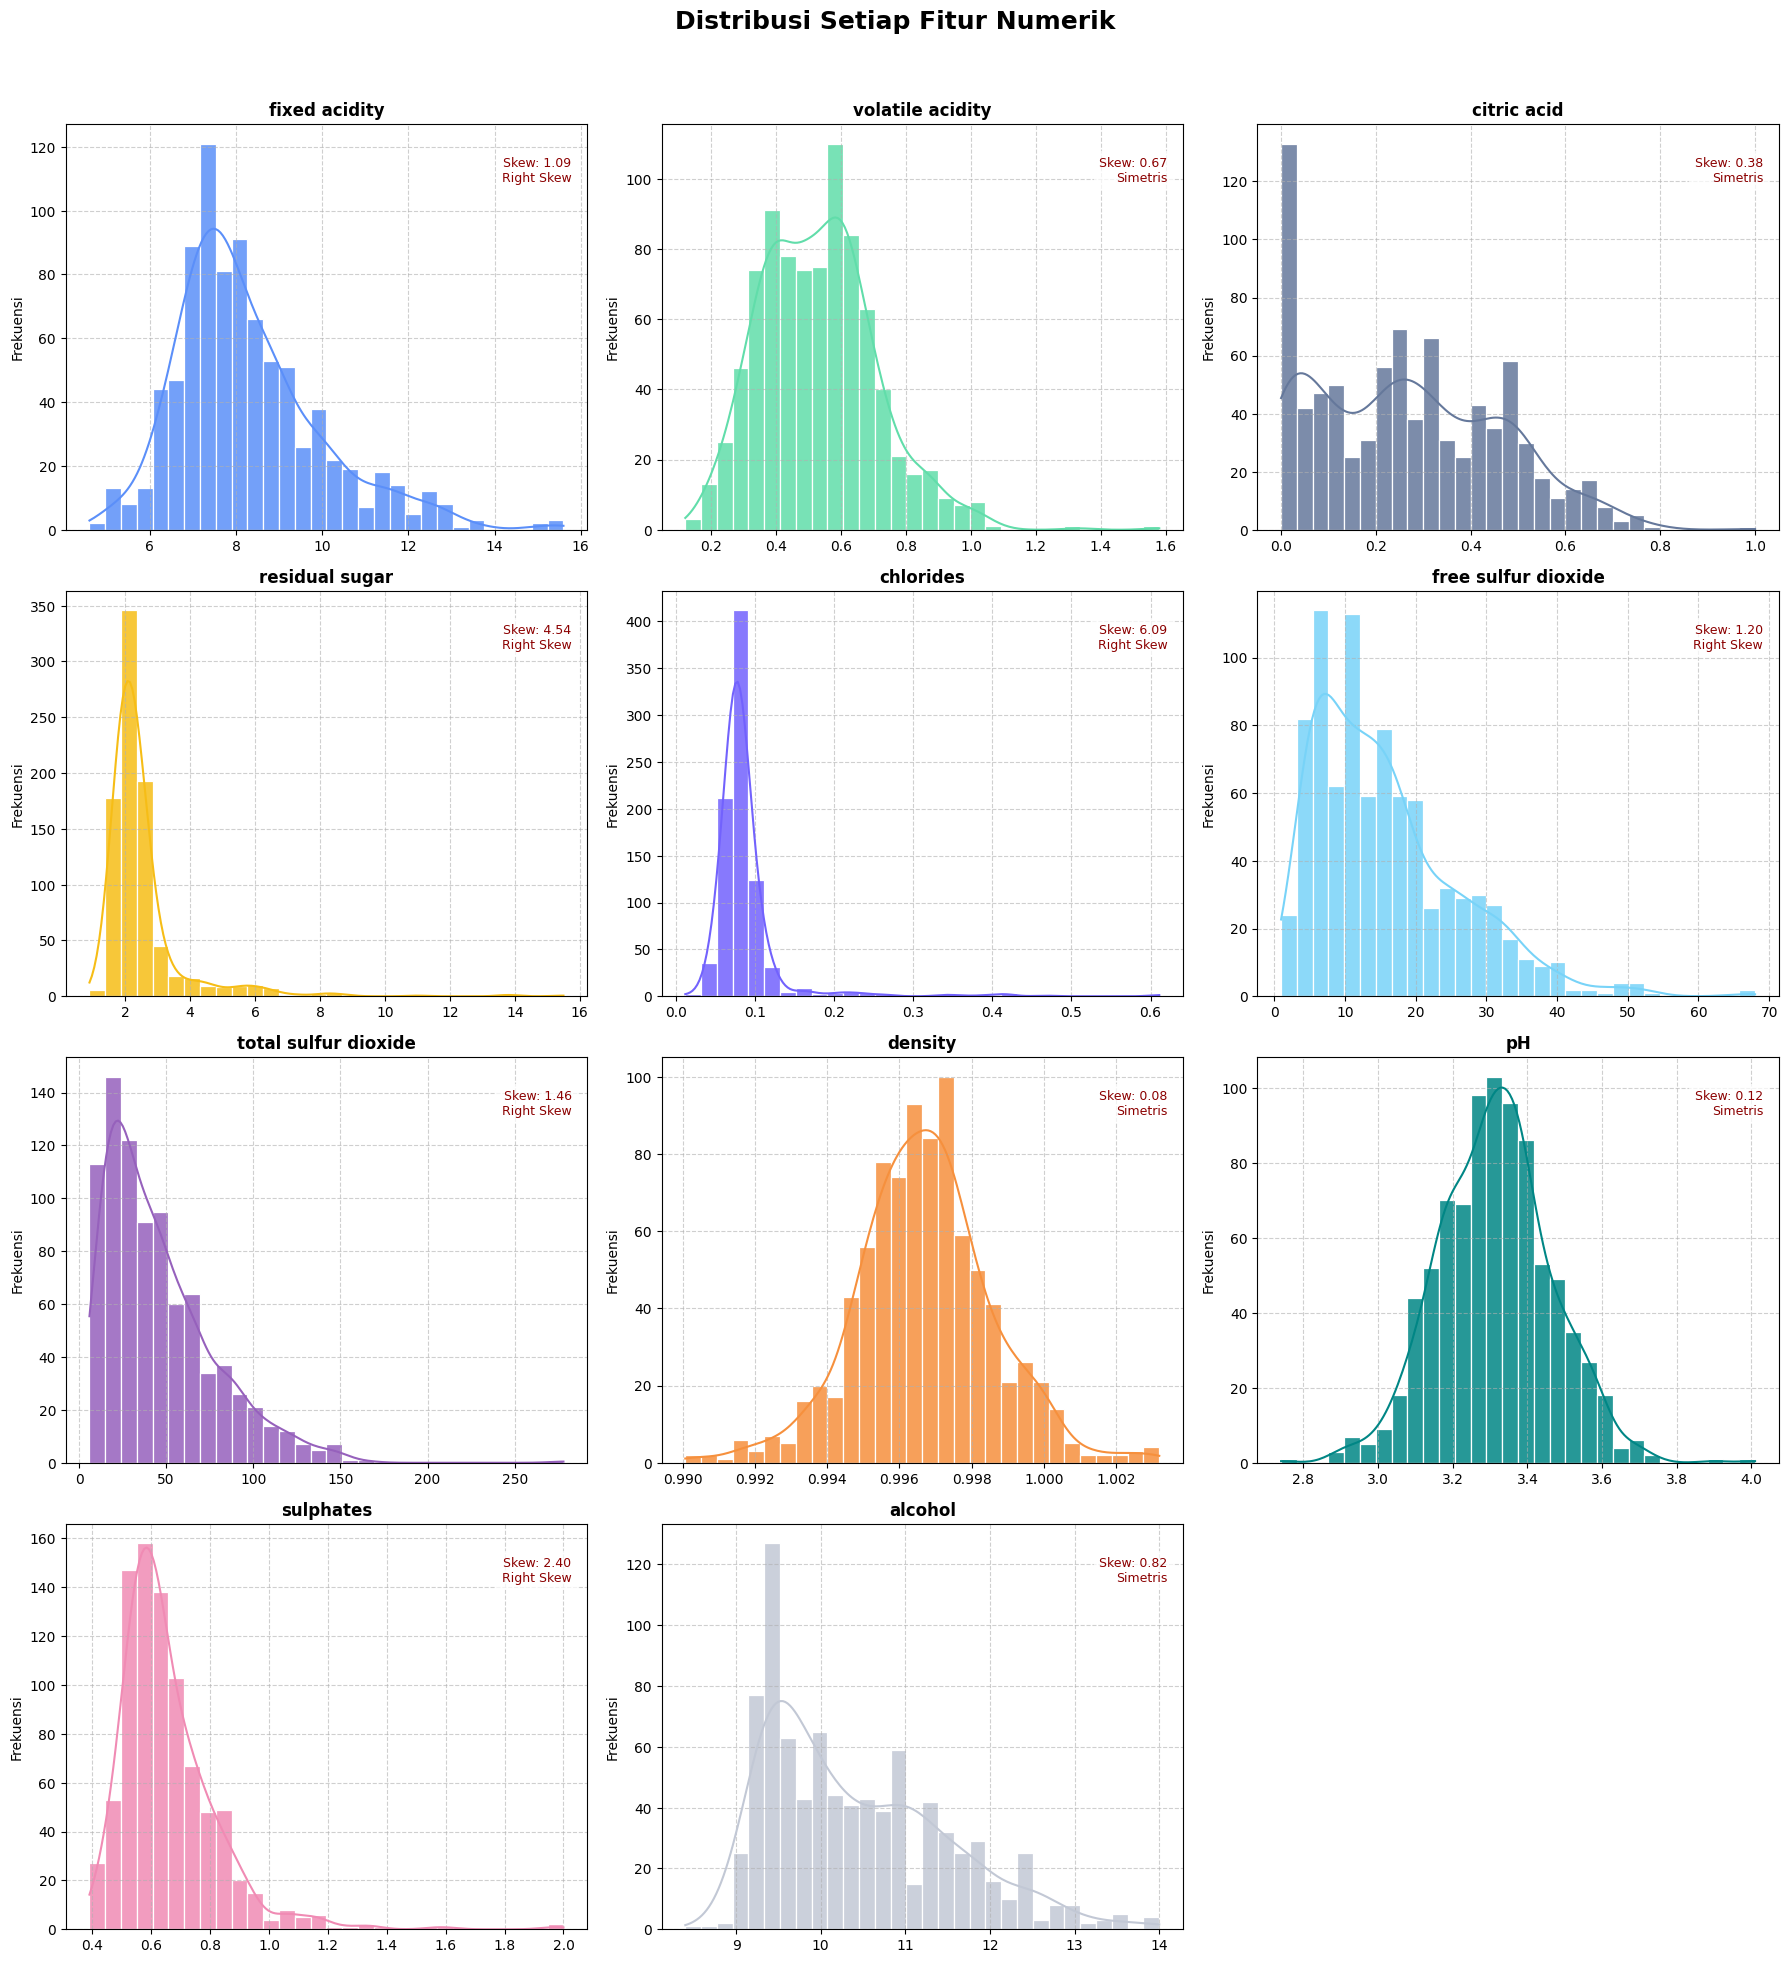

In [12]:
numeric_cols = df_train_raw.select_dtypes(include=['int64', 'float64']).columns
numeric_cols = numeric_cols.drop(['quality', 'Id'], errors='ignore')

n_cols = 3
n_rows = math.ceil(len(numeric_cols) / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(18, 4.8 * n_rows)
)

axes = axes.flatten()

colors = [
    '#5B8FF9', '#61DDAA', '#65789B',
    '#F6BD16', '#7262FD', '#78D3F8',
    '#9661BC', '#F6903D', '#008685',
    '#F08BB4', '#C2C8D5'
]

for i, col in enumerate(numeric_cols):

    skew_val = df_train_raw[col].skew()

    if skew_val > 1:
        skew_text = "Right Skew"
    elif skew_val < -1:
        skew_text = "Left Skew"
    else:
        skew_text = "Simetris"


    sns.histplot(
        df_train_raw[col],
        bins=30,
        kde=True,
        color=colors[i % len(colors)],
        edgecolor='white',
        alpha=0.85,
        ax=axes[i]
    )

    axes[i].set_title(
        f'{col}',
        fontsize=12,
        fontweight='bold'
    )

    axes[i].text(
        0.97,
        0.92,
        f'Skew: {skew_val:.2f}\n{skew_text}',
        transform=axes[i].transAxes,
        ha='right',
        va='top',
        fontsize=9,
        color='darkred',
        bbox=dict(
            facecolor='white',
            alpha=0.75,
            edgecolor='none'
        )
    )

    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frekuensi')

    axes[i].grid(
        alpha=0.6,
        linestyle='--'
    )

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle(
    'Distribusi Setiap Fitur Numerik',
    fontsize=18,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()
plt.show()

Berdasarkan visualisasi distribusi setiap fitur numerik, diperoleh beberapa temuan berikut:

- Sebagian besar fitur memiliki distribusi *right skew* (miring ke kanan) yang ditunjukkan oleh nilai skewness positif
- Fitur `residual sugar`, `chlorides`, `free sulfur dioxide`, `total sulfur dioxide`, dan `sulphates` menunjukkan tingkat skewness yang cukup tinggi sehingga mengindikasikan adanya potensi *outlier*
- Fitur `chlorides` dan `residual sugar` memiliki skewness paling tinggi, yaitu di atas 4, yang menunjukkan distribusi sangat tidak normal dengan beberapa nilai ekstrem
- Fitur `density` dan `pH` memiliki distribusi yang relatif simetris karena nilai skewness mendekati nol
- Distribusi beberapa fitur terlihat tidak mengikuti distribusi normal sehingga berpotensi memengaruhi performa model tertentu yang sensitif terhadap skala dan outlier

## 3.7 Korelasi Fitur terhadap Target

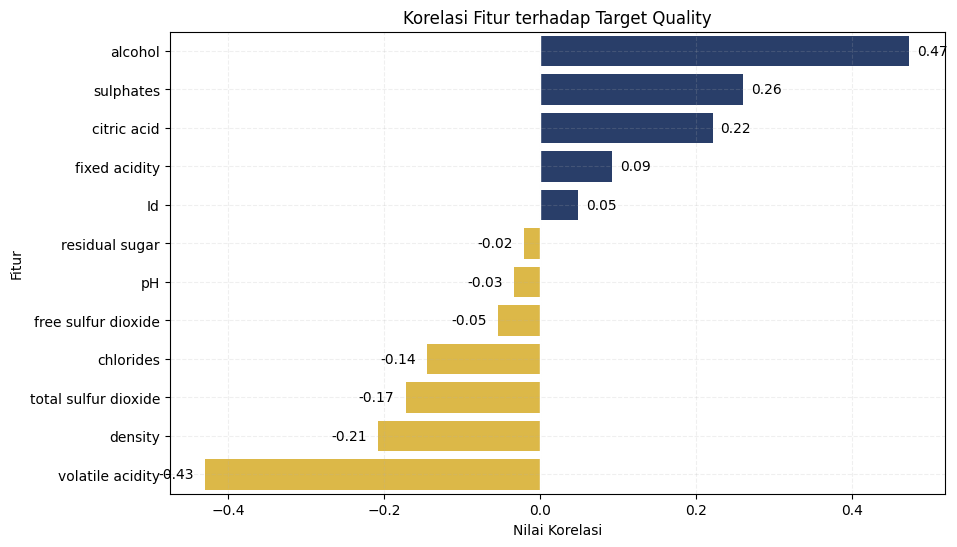

In [13]:
corr_target = (
    df_train_raw
    .corr(numeric_only=True)['quality']
    .drop('quality')
    .sort_values(ascending=False)
)

colors = [
    '#1f3b73' if v > 0 else '#f4c430'
    for v in corr_target.values
]

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x=corr_target.values,
    y=corr_target.index,
    hue=corr_target.index,
    palette=colors,
    dodge=False,
    legend=False
)
plt.axvline(
    x=0,
    color='white',
    linestyle='-',
    linewidth=1
)

for i, v in enumerate(corr_target.values):
    if v > 0:
        plt.text(
            v + 0.01,
            i,
            f'{v:.2f}',
            va='center',
            fontsize=10
        )
    else:
        plt.text(
            v - 0.06,
            i,
            f'{v:.2f}',
            va='center',
            fontsize=10
        )

plt.title('Korelasi Fitur terhadap Target Quality')
plt.xlabel('Nilai Korelasi')
plt.ylabel('Fitur')
plt.grid(
    alpha=0.2,
    linestyle='--'
)
plt.show()

Berdasarkan hasil korelasi terhadap variabel target `quality`, fitur `alcohol` memiliki korelasi positif tertinggi sebesar 0.47, sedangkan `volatile acidity` memiliki korelasi negatif tertinggi sebesar -0.43. Hal ini menunjukkan bahwa kadar alkohol cenderung meningkatkan kualitas wine, sementara tingkat keasaman volatil yang tinggi cenderung menurunkan kualitas wine.

Selain itu, fitur seperti `sulphates`, `citric acid`, `density`, dan `total sulfur dioxide` juga menunjukkan hubungan terhadap kualitas wine meskipun dengan kekuatan korelasi yang lebih rendah. Secara umum, seluruh fitur masih akan dipertahankan karena masing-masing berpotensi memberikan kontribusi terhadap proses klasifikasi.

## 3.8 Korelasi antar Fitur

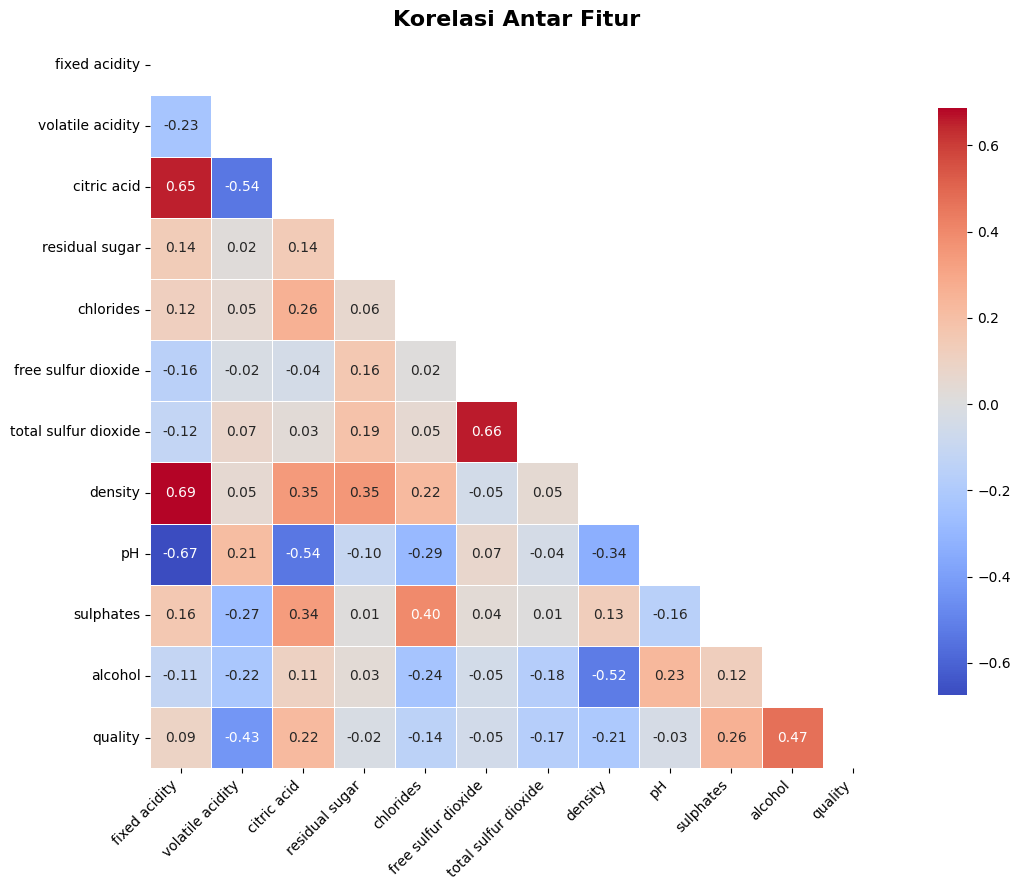

In [14]:
corr_matrix = (
    df_train_raw
    .drop(columns=['Id'], errors='ignore')
    .corr(numeric_only=True)
)

mask = np.triu(
    np.ones_like(corr_matrix, dtype=bool)
)


plt.figure(figsize=(12, 9))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5,
    linecolor='white',
    square=True,
    cbar_kws={'shrink': 0.8}
)

plt.title(
    'Korelasi Antar Fitur',
    fontsize=16,
    fontweight='bold'
)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Berdasarkan heatmap korelasi antar fitur, sebagian besar fitur memiliki tingkat korelasi rendah hingga sedang sehingga tidak terdapat indikasi multikolinearitas yang sangat kuat pada dataset.

Beberapa pasangan fitur dengan korelasi cukup tinggi antara lain:
- `fixed acidity` dan `density` dengan korelasi positif sebesar 0.69
- `fixed acidity` dan `pH` dengan korelasi negatif sebesar -0.67
- `free sulfur dioxide` dan `total sulfur dioxide` dengan korelasi positif sebesar 0.66
- `citric acid` dan `fixed acidity` dengan korelasi positif sebesar 0.65

Meskipun terdapat beberapa korelasi yang cukup tinggi, seluruh fitur masih dipertahankan karena nilai korelasi masih dalam batas yang dapat diterima dan masing-masing fitur berpotensi memberikan informasi penting dalam proses klasifikasi kualitas wine.

## 3.9 Deteksi Outlier

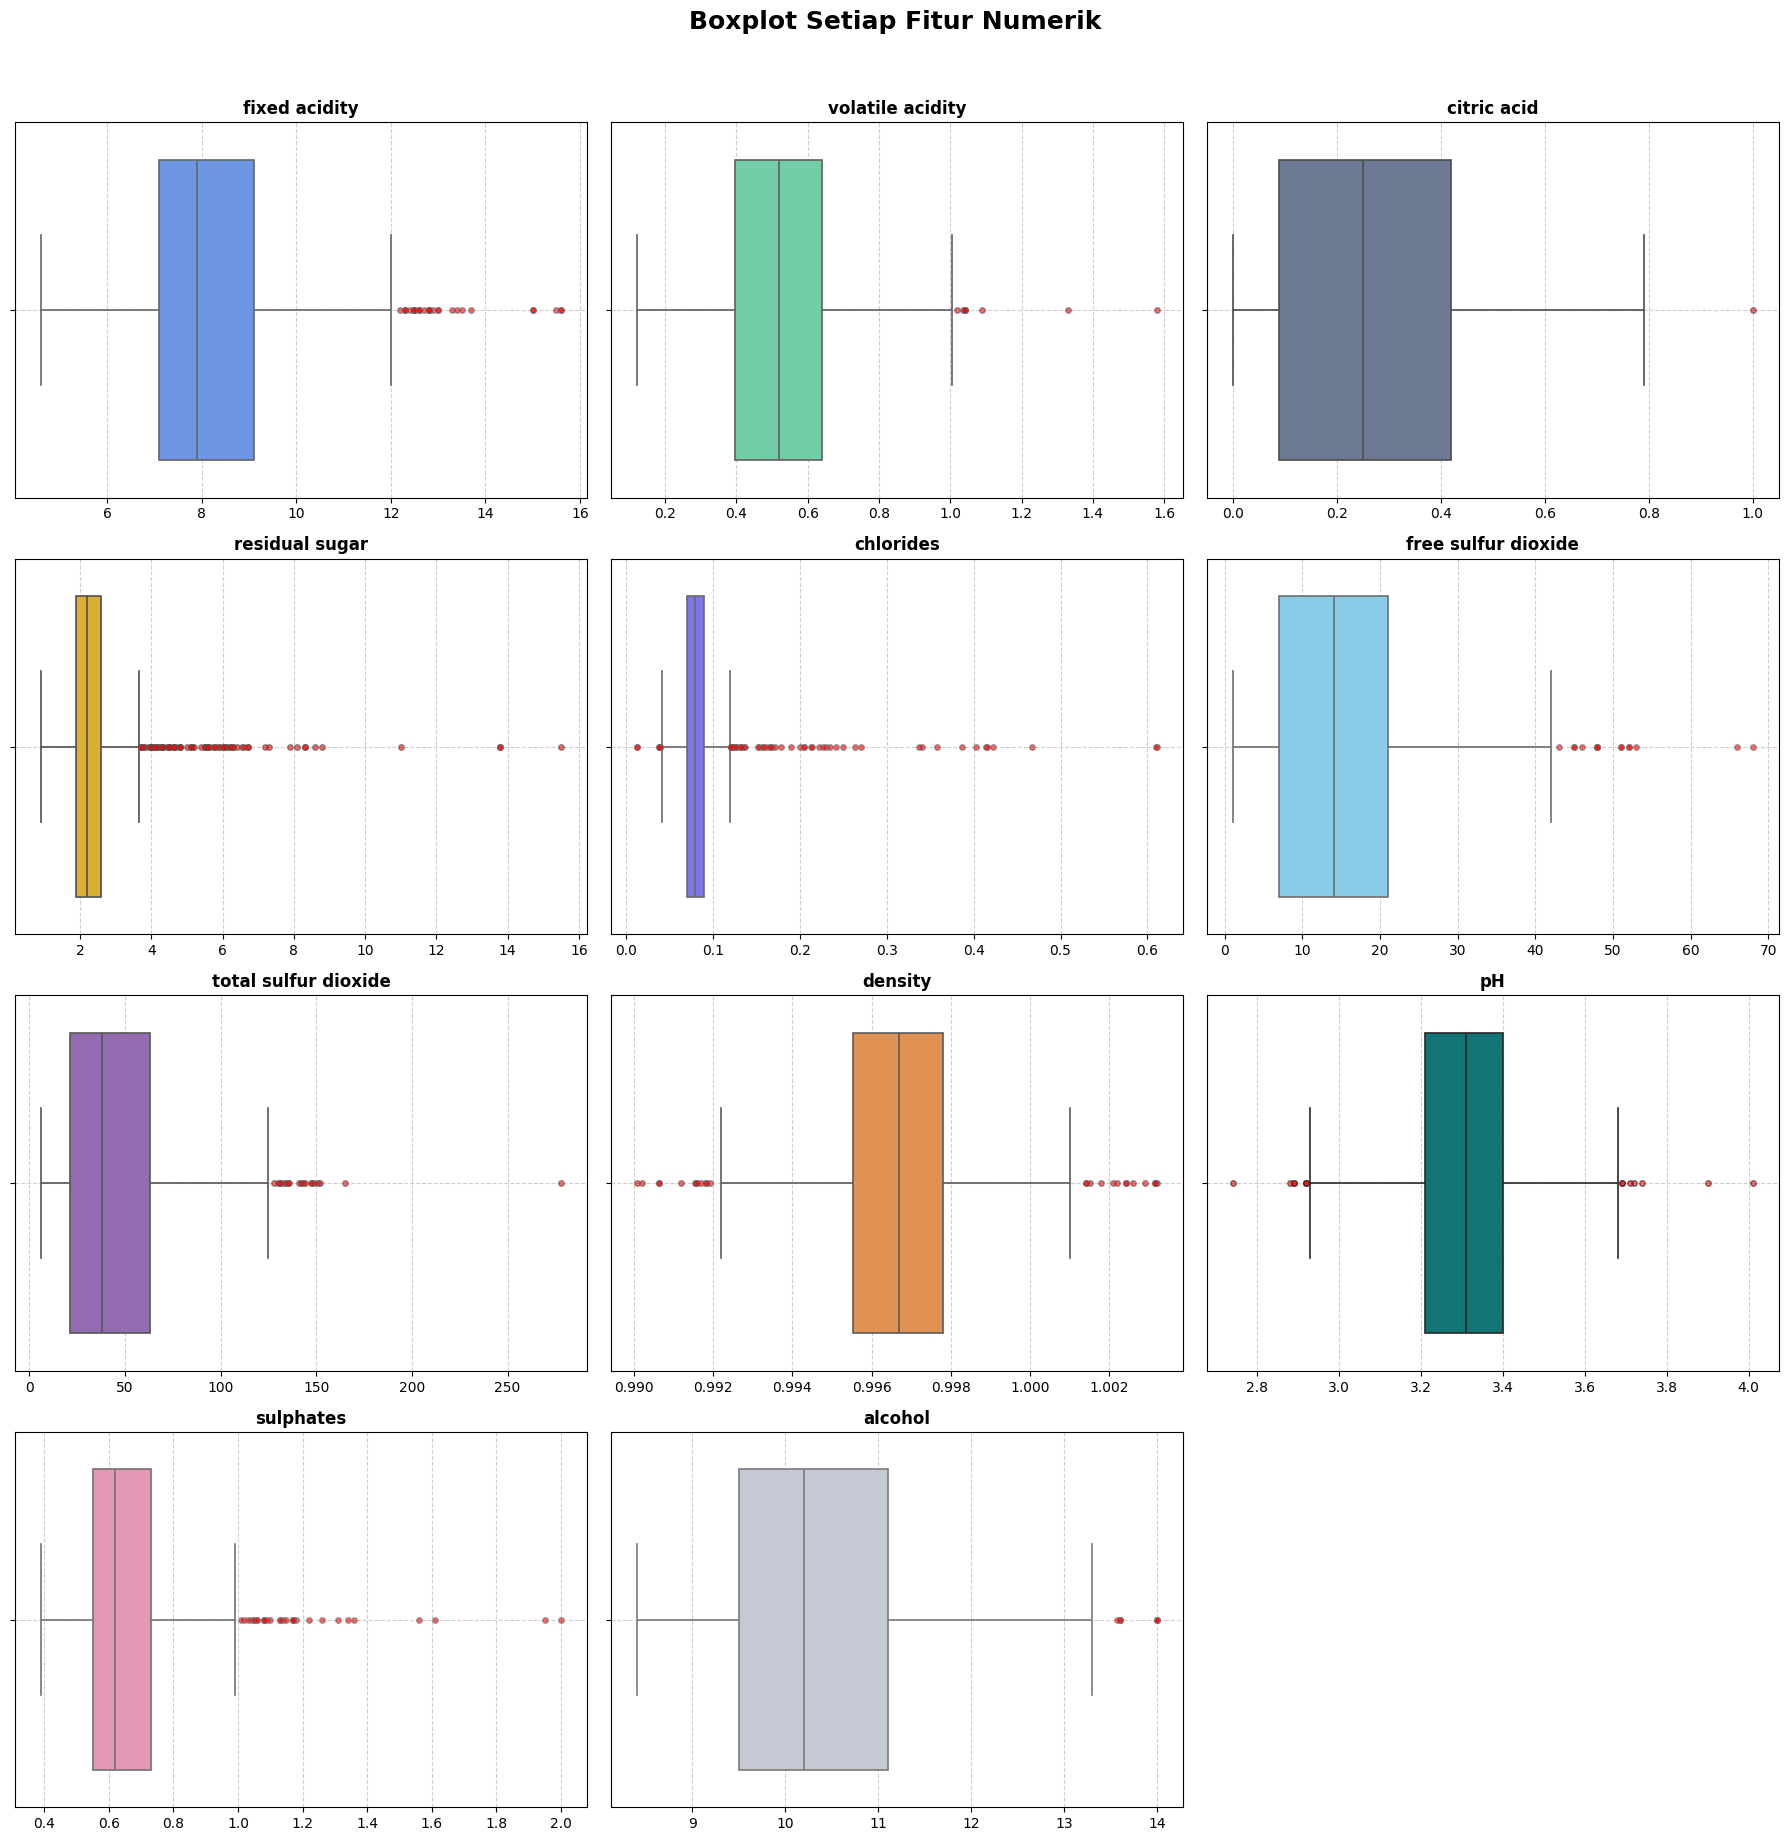

In [15]:
# Boxplot untuk setiap fitur numerik
numeric_cols = df_train_raw.select_dtypes(include=['int64', 'float64']).columns
numeric_cols = numeric_cols.drop(['quality', 'Id'], errors='ignore')

n_cols = 3
n_rows = math.ceil(len(numeric_cols) / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(18, 4.5 * n_rows)
)

axes = axes.flatten()

colors = [
    '#5B8FF9', '#61DDAA', '#65789B',
    '#F6BD16', '#7262FD', '#78D3F8',
    '#9661BC', '#F6903D', '#008685',
    '#F08BB4', '#C2C8D5'
]

for i, col in enumerate(numeric_cols):

    sns.boxplot(
        x=df_train_raw[col],
        color=colors[i % len(colors)],
        linewidth=1.2,
        flierprops={
            'marker': 'o',
            'markerfacecolor': 'red',
            'markersize': 4,
            'alpha': 0.6
        },
        ax=axes[i]
    )

    axes[i].set_title(
        f'{col}',
        fontsize=12,
        fontweight='bold'
    )

    axes[i].set_xlabel('')

    axes[i].grid(
        alpha=0.6,
        linestyle='--'
    )

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle(
    'Boxplot Setiap Fitur Numerik',
    fontsize=18,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()
plt.show()

In [16]:
# IQR
outlier_summary = []

for col in numeric_cols:

    Q1 = df_train_raw[col].quantile(0.25)
    Q3 = df_train_raw[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - (1.5 * IQR)
    upper_bound = Q3 + (1.5 * IQR)

    outliers = df_train_raw[
        (df_train_raw[col] < lower_bound) |
        (df_train_raw[col] > upper_bound)
    ]

    outlier_summary.append({
        'Fitur': col,
        'Jumlah Outlier': len(outliers),
        'Persentase Outlier (%)': round(
            (len(outliers) / len(df_train_raw)) * 100,
            2
        )
    })

outlier_df = pd.DataFrame(outlier_summary)

display(outlier_df.sort_values(
    by='Jumlah Outlier',
    ascending=False
))

,Fitur,Jumlah Outlier,Persentase Outlier (%)
3,residual sugar,76,8.87
4,chlorides,59,6.88
9,sulphates,31,3.62
0,fixed acidity,30,3.50
7,density,25,2.92
6,total sulfur dioxide,19,2.22
5,free sulfur dioxide,15,1.75
8,pH,14,1.63
10,alcohol,9,1.05
1,volatile acidity,8,0.93


Berdasarkan visualisasi boxplot dan deteksi menggunakan metode IQR, terlihat bahwa beberapa fitur memiliki jumlah *outlier* yang cukup tinggi, terutama pada fitur `residual sugar`, `chlorides`, dan `sulphates`. *Outlier* pada dataset tidak dihapus dengan beberapa pertimbangan berikut:

- Model yang digunakan didominasi oleh algoritma berbasis *tree-based* seperti Random Forest, Extra Trees, XGBoost, LightGBM, CatBoost, dan HistGradientBoosting yang relatif lebih robust terhadap keberadaan *outlier*
- Nilai ekstrem pada dataset wine berpotensi merepresentasikan kondisi kimiawi asli dari kualitas wine sehingga masih mengandung informasi penting
- Penghapusan *outlier* berisiko mengurangi jumlah data, terutama pada kelas minoritas yang sudah mengalami *imbalance*
- Beberapa fitur memang memiliki distribusi yang secara alami cenderung *right skew* sehingga nilai tinggi tidak selalu menunjukkan kesalahan data
- Penanganan *outlier* secara agresif dapat menyebabkan hilangnya variasi data yang penting dalam proses pembelajaran model

Oleh karena itu, *outlier* tetap **dipertahankan** agar model dapat mempelajari pola data secara lebih representatif.

# 4. Preprocessing

Preprocessing yang dilakukan meliputi:

- Pemisahan fitur (`X`) dan variabel target (`y`) serta menghapus kolom `Id` karena tidak memiliki relevansi terhadap proses klasifikasi
- Label encoding pada variabel target `quality` untuk mengubah label kelas menjadi representasi integer berurutan yang kompatibel dengan algoritma klasifikasi
- Pembagian dataset menjadi data training dan validation menggunakan `train_test_split` dengan `stratify=y` untuk menjaga proporsi distribusi kelas pada setiap subset data
- Normalisasi fitur menggunakan `RobustScaler` untuk mengurangi pengaruh *outlier* dan perbedaan skala antar fitur
- Penyeimbangan distribusi kelas menggunakan SMOTE untuk mengatasi permasalahan *class imbalance*

Menyalin dataset dilakukan untuk menjaga data asli tetap utuh sebagai referensi. Dengan demikian, setiap proses preprocessing dilakukan pada salinan data sehingga tidak memengaruhi data mentah.

In [17]:
df_train = df_train_raw.copy()

## 4.1 Pemisahan Fitur dan Target

Pada tahap ini dilakukan pemisahan antara fitur (*X*) dan variabel target (*y*). Kolom *Id* dihapus karena hanya berfungsi sebagai identitas unik dan tidak relevan dalam proses pemodelan, sedangkan kolom *quality* digunakan sebagai target yang akan diprediksi.

In [18]:
X = df_train.drop(columns=['quality', 'Id'])
y = df_train['quality']

print("X:", X.shape)
print("y:", y.shape)

X: (857, 11)
y: (857,)


## 4.2 Label Encoding

Dilakukan proses *label encoding* pada variabel target `quality`. Proses ini bertujuan untuk mengubah label kelas menjadi representasi integer berurutan agar kompatibel dengan algoritma klasifikasi machine learning, khususnya model seperti XGBoost.

In [19]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)

df_label = pd.DataFrame({
    'Label Asli': le.classes_,
    'Label Encoded': le.transform(le.classes_)
})

display(Markdown("### Label Encoding untuk Target quality"))
display(df_label)

### Label Encoding untuk Target quality

,Label Asli,Label Encoded
0,3,0
1,4,1
2,5,2
3,6,3
4,7,4
5,8,5


## 4.3 Membagi Data

Dataset dibagi menjadi data training dan data validation dengan rasio 80:20 menggunakan `train_test_split`. Pembagian dilakukan dengan parameter `stratify=y` untuk menjaga proporsi distribusi kelas pada kedua subset data tetap seimbang. Proses pemisahan data dilakukan sebelum tahap preprocessing lanjutan guna menghindari terjadinya *data leakage* selama proses pelatihan dan evaluasi model.

In [20]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    stratify=y_encoded,
    random_state=42
)

print("Train :", X_train.shape)
print("Val   :", X_val.shape)

Train : (685, 11)
Val   : (172, 11)


## 4.4 Normalisasi Fitur

Normalisasi fitur menggunakan `RobustScaler`, metode ini dipilih karena dataset memiliki beberapa *outlier* dan distribusi fitur yang cenderung tidak simetris (*skewed*). `RobustScaler` bekerja menggunakan median dan Interquartile Range (IQR) sehingga lebih robust terhadap nilai ekstrem dibandingkan metode normalisasi lainnya. Proses normalisasi dilakukan dengan menerapkan `fit` hanya pada data training, kemudian hasil transformasi diterapkan pada data validation. Pendekatan ini dilakukan untuk menghindari *data leakage* karena informasi dari data validation tidak digunakan selama proses pembelajaran scaler.

Proses normalisasi fitur menggunakan `RobustScaler` diterapkan di dalam pipeline selama tahap cross-validation sehingga proses *fit* hanya dilakukan pada data training di setiap fold. Pendekatan ini dilakukan untuk menghindari terjadinya *data leakage* dari data validasi.

In [21]:
scaler = RobustScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

display(Markdown("### Hasil Scaling dengan RobustScaler"))

df_x_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns
)
display(df_x_train_scaled.head())

### Hasil Scaling dengan RobustScaler

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,0.578947,1.06,-0.03125,-0.714286,-0.052632,-0.266667,-0.404762,0.116592,-0.10,0.294118,-0.058824
1,-0.368421,0.82,-0.62500,3.500000,0.368421,-0.666667,-0.642857,-0.206278,0.50,-1.352941,0.470588
2,-0.105263,-0.12,0.03125,-0.428571,-0.894737,-0.333333,-0.166667,-0.026906,0.40,0.117647,-0.294118
3,0.052632,-0.56,0.59375,-0.428571,1.000000,-0.533333,-0.547619,-0.475336,-0.05,0.117647,0.764706
4,-0.263158,0.24,-0.78125,-0.285714,-0.789474,-0.466667,-0.642857,-0.466368,0.70,-0.235294,0.705882


## 4.5 SMOTE

Penanganan *class imbalance* menggunakan metode SMOTE (*Synthetic Minority Over-sampling Technique*). Teknik ini digunakan untuk meningkatkan jumlah data pada kelas minoritas dengan membangkitkan sampel sintetis berdasarkan karakteristik data terdekat, sehingga distribusi kelas menjadi lebih seimbang dan model dapat belajar secara lebih optimal.

Penanganan *class imbalance* menggunakan SMOTE juga diterapkan di dalam pipeline pada setiap fold cross-validation sehingga oversampling hanya dilakukan pada data training. Dengan demikian, distribusi data validasi tetap merepresentasikan kondisi data asli dan evaluasi model menjadi lebih objektif.

In [22]:
smote = SMOTE(
    k_neighbors=2,
    random_state=42
)

X_train_resampled, y_train_resampled = smote.fit_resample(
    X_train_scaled,
    y_train
)

In [23]:
before_smote = Counter(y_train)
after_smote = Counter(y_train_resampled)
smote_comparison = pd.DataFrame({
    'Sebelum SMOTE': pd.Series(before_smote),
    'Sesudah SMOTE': pd.Series(after_smote)
})
smote_comparison.index.name = 'Quality'

display(Markdown("### Distribusi Kelas Sebelum dan Sesudah SMOTE"))
display(smote_comparison)

### Distribusi Kelas Sebelum dan Sesudah SMOTE

,Sebelum SMOTE,Sesudah SMOTE
Quality,,
2,289,289
3,273,289
4,87,289
1,21,289
5,10,289
0,5,289


# 5. Modeling

Pada tahap modeling dilakukan komparasi beberapa algoritma klasifikasi berbasis *tree ensemble* dan *boosting*, yaitu:

- Random Forest
- Extra Trees
- XGBoost
- LightGBM
- CatBoost
- HistGradientBoosting

Proses pelatihan model menggunakan *Stratified K-Fold Cross Validation* dengan `cv=5` untuk memperoleh evaluasi yang lebih stabil dan representatif. Selain itu, digunakan *pipeline* untuk memastikan proses preprocessing seperti normalisasi fitur dilakukan secara terpisah pada setiap fold sehingga dapat menghindari *data leakage*.

Beberapa skenario eksperimen juga dilakukan untuk membandingkan pengaruh penggunaan:
- StandardScaler dan RobustScaler
- SMOTE
- Class Weight Balancing

terhadap performa model klasifikasi.

Tahapan modeling yang dilakukan meliputi:

- Komparasi baseline model menggunakan parameter default dengan `cv=5` dan pipeline preprocessing
- Pemilihan 3 model terbaik berdasarkan hasil evaluasi baseline
- Hyperparameter tuning pada 3 model terbaik menggunakan `BayesSearchCV` menggunakan ruang pencarian yang telah ditentukan
- Pembangunan model ensemble menggunakan *Voting Classifier* dengan metode *soft voting*
- Komparasi akhir antara 3 model terbaik hasil tuning dan model ensemble voting
- Model dengan performa evaluasi terbaik dipilih sebagai final model

Evaluasi model dilakukan menggunakan beberapa metrik berikut:

- `F1-Score Macro` digunakan karena dataset memiliki kondisi *class imbalance* sehingga seluruh kelas dievaluasi secara seimbang tanpa dipengaruhi jumlah data tiap kelas
- `F1-Score Weighted` digunakan untuk mempertimbangkan performa model berdasarkan proporsi jumlah data pada setiap kelas
- `Accuracy` digunakan untuk melihat tingkat prediksi benar secara keseluruhan
- `Accuracy Std` digunakan untuk mengukur stabilitas performa model pada proses cross-validation. Semakin kecil nilai standar deviasi, maka performa model semakin konsisten pada setiap fold pengujian
- Metrik utama yang digunakan sebagai acuan pemilihan model adalah **`F1-Score Macro`**

Evaluasi detail hanya dilakukan pada final model menggunakan:

- Validation Set Metrics
- Classification Report
- Confusion Matrix
- Feature Importance

## 5.1 Komparasi Baseline Model

Pada tahap awal dilakukan komparasi baseline model untuk membandingkan performa awal dari beberapa algoritma klasifikasi menggunakan parameter default. Evaluasi dilakukan menggunakan *Stratified K-Fold Cross Validation* dengan `cv=5` serta pipeline preprocessing untuk memastikan proses normalisasi dan penanganan *class imbalance* dilakukan tanpa menyebabkan *data leakage*.

### 5.1.1 Definisi Baseline Model

In [24]:
# define model baseline
models_baseline = {

    "Random Forest": RandomForestClassifier(
        random_state=42,
        n_jobs=1
    ),

    "Extra Trees": ExtraTreesClassifier(
        random_state=42,
        n_jobs=1
    ),

    "XGBoost": XGBClassifier(
        eval_metric='mlogloss',
        random_state=42,
        n_jobs=1,
        verbosity=0
    ),

    "CatBoost": CatBoostClassifier(
        random_state=42,
        verbose=0
    ),

    "HistGB": HistGradientBoostingClassifier(
        random_state=42
    ),

    "LightGBM": LGBMClassifier(
        random_state=42,
        verbosity=-1,
        n_jobs=1
    )
}

### 5.1.2 Pipeline dan Cross Validation

In [25]:
def evaluate_cv_smote(model, model_name):

    # pipeline dengan RobustScaler dan SMOTE
    pipeline = Pipeline([

        ('scaler', RobustScaler()),
        
        ('smote', SMOTE(
            k_neighbors=2,
            random_state=42
        )),
        
        ('model', model)
    ])

    # cross val, k=5, stratified
    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    # metrik evaluasi
    scoring = {
        'accuracy': 'accuracy',
        'f1_macro': 'f1_macro',
        'f1_weighted': 'f1_weighted'
    }

    #
    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=1,
        error_score='raise'
    )

    return {
        'Model': model_name,

        'CV Accuracy': round(
            scores['test_accuracy'].mean(),
            4
        ),

        'CV Accuracy Std': round(
            scores['test_accuracy'].std(),
            4
        ),

        'CV F1 Macro': round(
            scores['test_f1_macro'].mean(),
            4
        ),

        'CV F1 Weighted': round(
            scores['test_f1_weighted'].mean(),
            4
        )
    }

### 5.1.3 Proses Training Baseline Model

In [26]:
cv_results_smote = []

total_models = len(models_baseline)

for idx, (model_name, model) in enumerate(
    models_baseline.items(),
    start=1
):

    print("=" * 60)
    print(f"[{idx}/{total_models}] Running Cross Validation : {model_name}")

    start_time = time.time()

    result = evaluate_cv_smote(
        model,
        model_name
    )

    cv_results_smote.append(result)

    elapsed = time.time() - start_time

    print(f"[DONE] {model_name}")
    print(f"Execution Time : {elapsed:.2f} sec")

print("=" * 60)
print("All Cross Validation Finished")

[1/6] Running Cross Validation : Random Forest
[DONE] Random Forest
Execution Time : 2.17 sec
[2/6] Running Cross Validation : Extra Trees
[DONE] Extra Trees
Execution Time : 1.06 sec
[3/6] Running Cross Validation : XGBoost
[DONE] XGBoost
Execution Time : 2.42 sec
[4/6] Running Cross Validation : CatBoost
[DONE] CatBoost
Execution Time : 21.40 sec
[5/6] Running Cross Validation : HistGB
[DONE] HistGB
Execution Time : 18.63 sec
[6/6] Running Cross Validation : LightGBM


/tf/workspace/VMD_DL/forecast_env_server/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/tf/workspace/VMD_DL/forecast_env_server/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/tf/workspace/VMD_DL/forecast_env_server/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/tf/workspace/VMD_DL/forecast_env_server/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[DONE] LightGBM
Execution Time : 3.70 sec
All Cross Validation Finished


/tf/workspace/VMD_DL/forecast_env_server/lib/python3.11/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


### 5.1.4 Hasil Evaluasi Baseline Model

In [28]:
cv_results_smote = pd.DataFrame(cv_results_smote)

cv_results_smote = cv_results_smote.sort_values(
    by='CV F1 Macro',
    ascending=False
).reset_index(drop=True)

cv_results_smote

,Model,CV Accuracy,CV Accuracy Std,CV F1 Macro,CV F1 Weighted
0,CatBoost,0.5985,0.0288,0.3684,0.5991
1,Extra Trees,0.6058,0.0261,0.3520,0.5990
2,Random Forest,0.5942,0.0164,0.3495,0.5898
3,XGBoost,0.6015,0.0229,0.3482,0.5995
4,HistGB,0.5927,0.0460,0.3378,0.5918
5,LightGBM,0.5839,0.0249,0.3292,0.5818


Dilakukan beberapa eksperimen kombinasi preprocessing dan penanganan class imbalance meliputi:

- StandardScaler
- RobustScaler
- SMOTE
- Weighted model

Ringkasan hasil eksperimen ditunjukkan pada tabel berikut.
<h3>Ringkasan Hasil Eksperimen</h3>

<img src="hasil_eksperimen1.png" width="1000">
<br><br>
<img src="hasil_eksperimen2.png" width="1000">


Berdasarkan hasil evaluasi cross-validation, konfigurasi yang digunakan pada penelitian ini adalah **RobustScaler**, **SMOTE**, dan model tanpa `class_weight` (non-weighted). Penggunaan class_weight tidak memberikan peningkatan performa yang signifikan setelah data diseimbangkan menggunakan SMOTE, sehingga pendekatan non-weighted dipilih karena lebih sederhana dan stabil.

Pemilihan model terbaik dilakukan berdasarkan metrik F1 Macro karena lebih representatif dalam mengevaluasi performa klasifikasi pada data tidak seimbang. Berdasarkan hasil pengujian, tiga model terbaik adalah:

1. CatBoost — F1 Macro: 0.3684
2. Extra Trees — F1 Macro: 0.3520
3. Random Forest — F1 Macro: 0.3495

Ketiga model tersebut dipilih untuk tahap tuning dan evaluasi lanjutan karena menunjukkan performa F1 Macro tertinggi serta stabilitas yang baik pada proses cross-validation.

## 5.2 Optimasi Hyperparameter

Berdasarkan hasil komparasi model baseline, tiga model yang dipilih untuk tahap optimasi hyperparameter adalah CatBoost, Extra Trees, dan Random Forest. Proses tuning menggunakan konfigurasi `RobustScaler`, `SMOTE`, dan pendekatan non-weighted tanpa `class_weight`.

Optimasi dilakukan menggunakan `BayesSearchCV` dengan `Pipeline` dan `StratifiedKFold (cv=5)` untuk mencegah *data leakage* serta menjaga distribusi kelas pada setiap *fold*. Masing-masing model dioptimasi sebanyak 50 iterasi.

Evaluasi model menggunakan metrik `Accuracy`, `Accuracy Std`, `F1-Score Macro`, dan `F1-Score Weighted`, dengan metrik utama yang digunakan sebagai acuan pemilihan model terbaik adalah `F1-Score Macro`.

### 5.2.1 Ruang Pencarian Hyperparameter (*Search Space*)

In [34]:
rf_space = {
    "model__n_estimators": Integer(100, 500),
    "model__max_depth": Integer(3, 30),
    "model__min_samples_split": Integer(2, 20),
    "model__min_samples_leaf": Integer(1, 10),
    "model__max_features": Categorical(["sqrt", "log2"]),
    "model__bootstrap": Categorical([True, False])
}

et_space = {
    "model__n_estimators": Integer(100, 500),
    "model__max_depth": Integer(3, 30),
    "model__min_samples_split": Integer(2, 20),
    "model__min_samples_leaf": Integer(1, 10),
    "model__max_features": Categorical(["sqrt", "log2"]),
    "model__bootstrap": Categorical([True, False])
}

catboost_space = {
    "model__iterations": Integer(100, 500),
    "model__depth": Integer(4, 10),
    "model__learning_rate": Real(0.01, 0.3, prior="log-uniform"),
    "model__l2_leaf_reg": Integer(1, 10),
    "model__border_count": Integer(32, 255)
}

models_tuning = {
    "Random Forest": (
        RandomForestClassifier(random_state=42),
        rf_space
    ),
    "Extra Trees": (
        ExtraTreesClassifier(random_state=42),
        et_space
    ),
    "CatBoost": (
        CatBoostClassifier(
            random_state=42,
            verbose=0,
            thread_count=1
        ),
        catboost_space
    )
}

### 5.2.2 Proses Optimasi

Proses optimasi hyperparameter dilakukan menggunakan `BayesSearchCV` dengan `Pipeline` yang terdiri dari `RobustScaler`, `SMOTE`, dan model klasifikasi. Optimasi dilakukan menggunakan `StratifiedKFold (cv=5)` dengan metrik utama `F1-Score Macro`. Setiap model dioptimasi sebanyak 50 iterasi untuk mendapatkan kombinasi parameter terbaik.

In [35]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

results_tuning = []
best_models = {}
best_searches = {}

for name, (model, space) in models_tuning.items():

    print(f"\nTuning {name}...")

    pipeline = Pipeline([
        ("scaler", RobustScaler()),
        ("smote", SMOTE(k_neighbors=2,random_state=42)),
        ("model", model)
    ])

    bayes_search = BayesSearchCV(
        estimator=pipeline,
        search_spaces=space,
        n_iter=50,
        scoring="f1_macro",
        cv=cv,
        n_jobs=-1,
        verbose=1,
        random_state=42
    )

    start = time.time()

    bayes_search.fit(X_train, y_train)

    end = time.time()

    best_models[name] = bayes_search.best_estimator_
    best_searches[name] = bayes_search

    results_tuning.append({
        "Model": name,
        "Best F1 Macro": round(bayes_search.best_score_, 4),
        "Best Params": bayes_search.best_params_,
        "Time (s)": round(end - start, 2)
    })

    print(f"Best F1 Macro: {bayes_search.best_score_:.4f}")
    print(f"Best Params: {bayes_search.best_params_}")
    print(f"Training Time: {round(end - start, 2)} seconds")


Tuning Random Forest...
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 c

### 5.2.3 Hasil Optimasi Hyperparameter

In [36]:
results_tuning_df = pd.DataFrame(results_tuning)

results_tuning_df.sort_values(
    by="Best F1 Macro",
    ascending=False
)

,Model,Best F1 Macro,Best Params,Time (s)
0,Random Forest,0.3874,"{'model__bootstrap': False, 'model__max_depth'...",149.84
1,Extra Trees,0.3853,"{'model__bootstrap': True, 'model__max_depth':...",88.44
2,CatBoost,0.3776,"{'model__border_count': 32, 'model__depth': 10...",1419.05


In [38]:
display(Markdown("### Perbandingan F1-Score Macro Sebelum dan Sesudah Hyperparameter Tuning"))

df_comparison = baseline_compare.merge(
    results_tuning_df[["Model", "Best F1 Macro"]],
    on="Model"
)

df_comparison = df_comparison[
    ["Model", "Baseline F1 Macro", "Best F1 Macro"]
]

df_comparison["Improvement"] = (
    df_comparison["Best F1 Macro"] -
    df_comparison["Baseline F1 Macro"]
).round(4)

display(df_comparison)

### Perbandingan F1-Score Macro Sebelum dan Sesudah Hyperparameter Tuning

,Model,Baseline F1 Macro,Best F1 Macro,Improvement
0,CatBoost,0.3684,0.3776,0.0092
1,Extra Trees,0.3520,0.3853,0.0333
2,Random Forest,0.3495,0.3874,0.0379


Seluruh model mengalami peningkatan performa setelah proses *hyperparameter tuning* berdasarkan metrik `F1-Score Macro`.
- `Random Forest` memberikan peningkatan terbesar sebesar `0.0379`, dari `0.3495` menjadi `0.3874`.
- `Extra Trees` mengalami peningkatan sebesar `0.0333`, dari `0.3520` menjadi `0.3853`.
- `CatBoost` mengalami peningkatan paling kecil sebesar `0.0092`, dari `0.3684` menjadi `0.3776`.
- Hasil tuning menunjukkan bahwa model berbasis *ensemble bagging* memberikan peningkatan performa yang lebih signifikan dibandingkan model *boosting* pada dataset penelitian ini.

## 5.3 Ensemble Voting

Ensemble Voting dilakukan menggunakan metode *soft voting* dengan menggabungkan model terbaik hasil hyperparameter tuning, yaitu Random Forest, Extra Trees, dan CatBoost. Metode *soft voting* dipilih karena mempertimbangkan nilai probabilitas prediksi dari setiap model sehingga mampu menghasilkan prediksi yang lebih stabil dan optimal dibandingkan *hard voting* yang hanya berdasarkan hasil voting label kelas.

In [41]:
ensemble_voting = VotingClassifier(
    estimators=[
        ("rf", best_models["Random Forest"]),
        ("et", best_models["Extra Trees"]),
        ("cat", best_models["CatBoost"])
    ],
    voting="soft",
    n_jobs=1
)

ensemble_voting.fit(X_train, y_train)

best_models["Ensemble Voting"] = ensemble_voting

## 5.4 Evaluasi Final Model

### 5.4.1 Komparasi Best Model

In [43]:
final_results = []

for name, model in best_models.items():

    y_pred = model.predict(X_val)

    final_results.append({
        "Model": name,
        "Accuracy": round(accuracy_score(y_val, y_pred), 4),
        "F1 Macro": round(f1_score(y_val, y_pred, average="macro"), 4),
        "F1 Weighted": round(f1_score(y_val, y_pred, average="weighted"), 4)
    })

final_results_df = pd.DataFrame(final_results)

display(
    final_results_df.sort_values(
        by="F1 Macro",
        ascending=False
    )
)

,Model,Accuracy,F1 Macro,F1 Weighted
1,Extra Trees,0.6105,0.3824,0.6022
3,Ensemble Voting,0.5988,0.3778,0.5942
0,Random Forest,0.5930,0.3695,0.5833
2,CatBoost,0.5698,0.3393,0.5744


- Berdasarkan hasil evaluasi final, `Extra Trees` memperoleh performa terbaik dengan nilai `Accuracy` sebesar `0.6105` dan `F1-Score Macro` sebesar `0.3824`.
- `Ensemble Voting` menghasilkan performa yang cukup kompetitif dengan `F1-Score Macro` sebesar `0.3778`, namun masih berada di bawah model `Extra Trees`.
- `Random Forest` menunjukkan performa yang stabil dengan `F1-Score Macro` sebesar `0.3695`.
- `CatBoost` memperoleh performa paling rendah dibandingkan model lainnya pada tahap evaluasi final.
- Hasil ini menunjukkan bahwa metode `Ensemble Voting` tidak selalu menghasilkan performa yang lebih baik dibandingkan model tunggal terbaik pada dataset ini.

### 5.4.2 Evaluasi Final Model

Berdasarkan hasil komparasi model pada tahap evaluasi final, `Extra Trees` memperoleh performa terbaik dengan nilai `Accuracy` sebesar `0.6105` dan `F1-Score Macro` sebesar `0.3824`. Hasil tersebut menunjukkan bahwa model `Extra Trees` memiliki kemampuan klasifikasi yang lebih baik dibandingkan model lainnya.

Oleh karena itu, model `Extra Trees` dipilih sebagai model terbaik dan selanjutnya dilakukan evaluasi lebih lanjut menggunakan *classification report* dan *confusion matrix* untuk menganalisis performa model pada setiap kelas secara lebih detail.

Classification Report
              precision    recall  f1-score   support

           3     0.0000    0.0000    0.0000         1
           4     0.0000    0.0000    0.0000         5
           5     0.6747    0.7671    0.7179        73
           6     0.5873    0.5441    0.5649        68
           7     0.5238    0.5000    0.5116        22
           8     1.0000    0.3333    0.5000         3

    accuracy                         0.6105       172
   macro avg     0.4643    0.3574    0.3824       172
weighted avg     0.6030    0.6105    0.6022       172



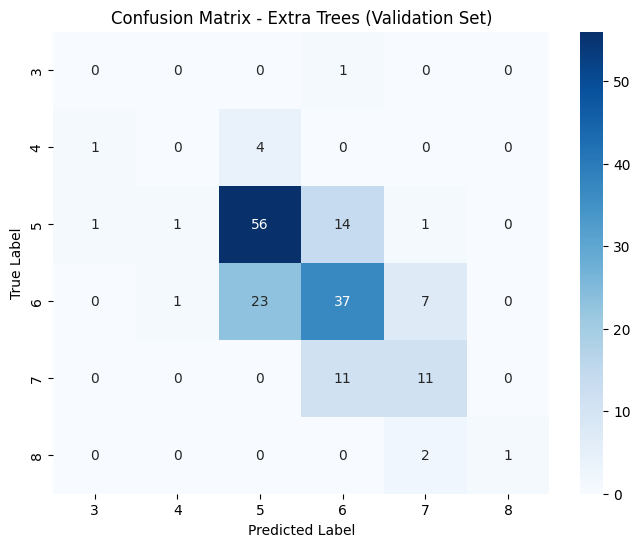

In [56]:
best_final_model = best_models["Extra Trees"]
y_pred = best_final_model.predict(X_val)

# reverse label encoding untuk target
target_names = [str(x) for x in le.classes_]

print("Classification Report")

print(classification_report(
    y_val,
    y_pred,
    target_names=target_names,
    digits=4
))

cm = confusion_matrix(y_val, y_pred)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=target_names,
    yticklabels=target_names
)

plt.title("Confusion Matrix - Extra Trees (Validation Set)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

- Model `Extra Trees` memperoleh nilai `Accuracy` sebesar **0.6105**, yang menunjukkan bahwa model mampu melakukan prediksi dengan benar terhadap sekitar 61.05% data pada validation set.

- Nilai `F1-Score Macro` sebesar **0.3824** menunjukkan bahwa performa model pada seluruh kelas masih belum merata, terutama pada kelas minoritas dengan jumlah data yang sangat sedikit.

- Nilai `F1-Score Weighted` sebesar **0.6022** menunjukkan bahwa model memiliki performa yang cukup baik pada kelas mayoritas yang mendominasi dataset.

- Berdasarkan *classification report*, model memiliki performa terbaik pada kelas **5** dengan:
  - `Precision` sebesar **0.6747**
  - `Recall` sebesar **0.7671**
  - `F1-Score` sebesar **0.7179**

  Hal ini menunjukkan bahwa model mampu mengenali kelas **5** dengan cukup baik dan konsisten.

- Pada kelas **6**, model juga menunjukkan performa yang cukup stabil dengan `F1-Score` sebesar **0.5649**. Namun, masih terdapat beberapa kesalahan klasifikasi ke kelas **5** dan **7**.

- Kelas **7** memperoleh `F1-Score` sebesar **0.5116**, yang menunjukkan bahwa model masih mengalami kesulitan dalam membedakan karakteristik kelas tersebut secara optimal.

- Kelas minoritas seperti kelas **3** dan **4** memiliki nilai `Precision`, `Recall`, dan `F1-Score` sebesar **0.0000**. Hal ini menunjukkan bahwa model gagal mengenali kelas tersebut pada validation set akibat jumlah data yang sangat sedikit.

- Berdasarkan confusion matrix, sebagian besar prediksi terkonsentrasi pada kelas **5** dan **6**, yang merupakan kelas dengan jumlah data terbesar pada dataset.

- Terlihat bahwa:
  - Sebanyak `14` data kelas **5** diprediksi sebagai kelas **6**
  - Sebanyak `23` data kelas **6** diprediksi sebagai kelas **5**
  - Sebagian data kelas **7** diprediksi sebagai kelas **6**

  Hal ini menunjukkan adanya kemiripan karakteristik antar kelas sehingga model mengalami kesulitan dalam memisahkan batas keputusan (*decision boundary*) secara optimal.

- Secara keseluruhan, model `Extra Trees` mampu memberikan performa yang cukup baik pada kelas mayoritas dan berhasil menjadi model terbaik dibandingkan model lainnya. Namun, performa pada kelas minoritas masih menjadi tantangan utama akibat ketidakseimbangan distribusi data pada dataset.

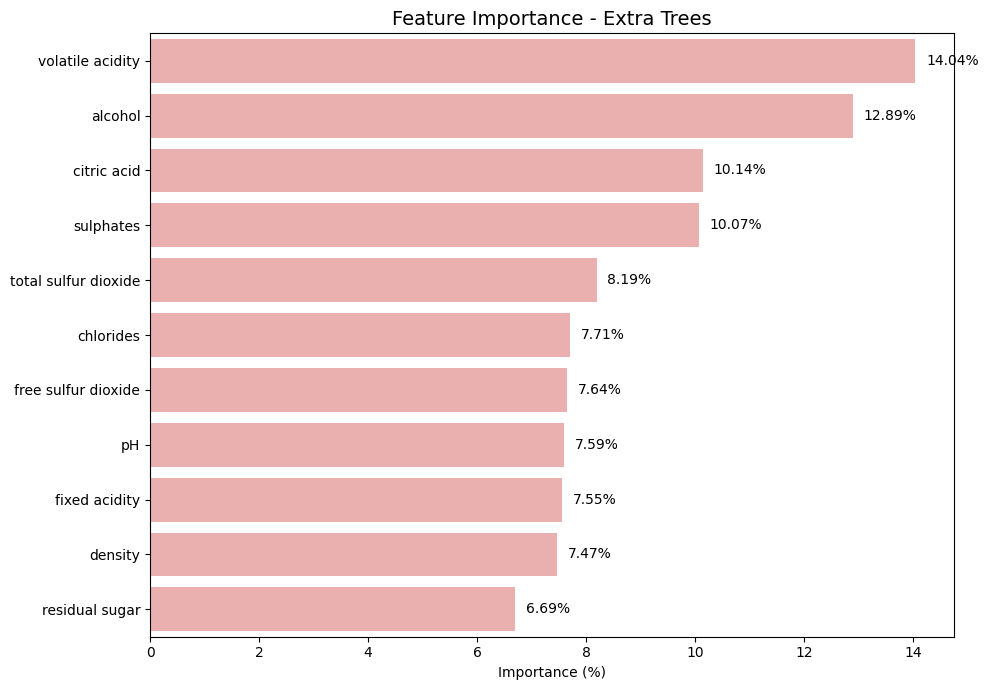

,Feature,Importance (%)
1,volatile acidity,14.0445%
10,alcohol,12.8920%
2,citric acid,10.1420%
9,sulphates,10.0699%
6,total sulfur dioxide,8.1922%
4,chlorides,7.7110%
5,free sulfur dioxide,7.6412%
8,pH,7.5864%
0,fixed acidity,7.5540%
7,density,7.4749%


In [64]:
best_final_model = best_models["Extra Trees"]

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance (%)": (
        best_final_model.named_steps["model"].feature_importances_ * 100
    )
})

feature_importance = feature_importance.sort_values(
    by="Importance (%)",
    ascending=False
)

plt.figure(figsize=(10, 7))

ax = sns.barplot(
    data=feature_importance,
    x="Importance (%)",
    y="Feature",
    color="#f4a6a6"
)

for i, value in enumerate(feature_importance["Importance (%)"]):
    ax.text(
        value + 0.2,
        i,
        f"{value:.2f}%",
        va="center",
        fontsize=10
    )

plt.title("Feature Importance - Extra Trees", fontsize=14)
plt.xlabel("Importance (%)")
plt.ylabel("")

plt.tight_layout()
plt.show()

display(
    feature_importance.style.format({
        "Importance (%)": "{:.4f}%"
    })
)

- Berdasarkan hasil *feature importance*, fitur `volatile acidity` menjadi fitur paling berpengaruh dalam proses klasifikasi dengan kontribusi sebesar **14.04%**.

- Fitur `alcohol` memiliki kontribusi sebesar **12.89%**, menunjukkan bahwa kadar alkohol memiliki pengaruh yang cukup besar terhadap proses prediksi kualitas data.

- Fitur `citric acid` dan `sulphates` juga memberikan kontribusi tinggi dengan nilai masing-masing sebesar **10.14%** dan **10.07%**.

- Fitur `total sulfur dioxide`, `chlorides`, dan `free sulfur dioxide` memiliki tingkat pengaruh menengah dengan kontribusi di kisaran **7%–8%**.

- Sementara itu, fitur `residual sugar` menjadi fitur dengan kontribusi paling rendah sebesar **6.69%**, namun tetap memberikan pengaruh terhadap proses klasifikasi model.

- Secara keseluruhan, seluruh fitur memiliki kontribusi yang relatif seimbang tanpa adanya dominasi fitur yang terlalu ekstrem. Hal ini menunjukkan bahwa model `Extra Trees` memanfaatkan kombinasi berbagai fitur dalam melakukan proses klasifikasi.

- Hasil *feature importance* juga menunjukkan bahwa karakteristik kimia seperti tingkat keasaman (*acidity*), kandungan alkohol, dan kandungan sulfur memiliki pengaruh penting dalam menentukan hasil klasifikasi pada dataset penelitian.

# 6. Final Fit

Berdasarkan hasil evaluasi final model, `Extra Trees` dipilih sebagai model terbaik karena memperoleh performa tertinggi dibandingkan model lainnya. Oleh karena itu, model tersebut selanjutnya dilatih kembali menggunakan seluruh dataset agar dapat memanfaatkan seluruh informasi data yang tersedia dan menghasilkan model final yang lebih optimal sebelum proses penyimpanan model dilakukan.

In [65]:
final_model = best_searches["Extra Trees"].best_estimator_
final_model.fit(X, y_encoded)

print("Final model berhasil dilatih pada seluruh dataset.")

Final model berhasil dilatih pada seluruh dataset.


# 7. Simpan Model

Model final yang telah dilatih menggunakan seluruh dataset selanjutnya disimpan agar dapat digunakan kembali pada proses prediksi tanpa perlu melakukan pelatihan ulang model.

In [78]:
joblib.dump(final_model, "extra_trees_final_model.pkl")
joblib.dump(le, "label_encoder.pkl")

print("Model dan label encoder berhasil disimpan")

Model dan label encoder berhasil disimpan


# 8. Prediksi

Model yang telah disimpan selanjutnya digunakan untuk melakukan proses prediksi pada data baru. Pada tahap ini, model dan label encoder akan dimuat kembali akan digunakan untuk memprediksi data_testing.csv (df_testing_raw).

In [79]:
# load model
loaded_model = joblib.load("extra_trees_final_model.pkl")
loaded_le = joblib.load("label_encoder.pkl")

print("Model dan label encoder berhasil dimuat.")

Model dan label encoder berhasil dimuat.


In [80]:
loaded_model = joblib.load("extra_trees_final_model.pkl")
loaded_le = joblib.load("label_encoder.pkl")

X_testing = df_testing_raw.drop(columns=["Id"])
predictions_encoded = loaded_model.predict(X_testing)
predictions = loaded_le.inverse_transform(predictions_encoded)
hasil_prediksi = pd.DataFrame({
    "Id": df_testing_raw["Id"],
    "Quality": predictions
})

display(hasil_prediksi)

,Id,Quality
0,222,5
1,1514,6
2,417,5
3,754,5
4,516,5
...,...,...
281,1147,7
282,296,5
283,170,5
284,1439,5


In [81]:
prediction_distribution = (
    hasil_prediksi["Quality"]
    .value_counts()
    .sort_index()
)

for Quality, total in prediction_distribution.items():
    print(f"Quality {Quality} = {total} buah")

Quality 3 = 1 buah
Quality 4 = 6 buah
Quality 5 = 127 buah
Quality 6 = 109 buah
Quality 7 = 42 buah
Quality 8 = 1 buah


In [82]:
hasil_prediksi.to_csv("hasilprediksi_035.csv", sep=";", index=False)

print("Berhasil disimpan.")

Berhasil disimpan.
